Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


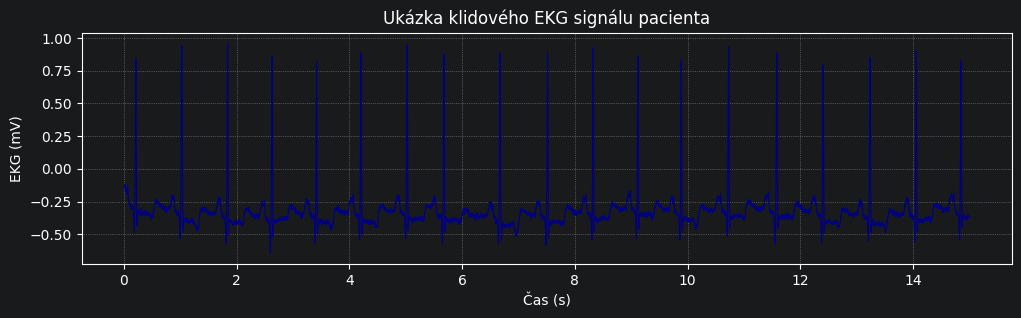

In [1]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

files_klid = sorted(glob.glob("ekg_klid/*.txt"))
files_zatez = sorted(glob.glob("ekg_zatez/*.txt"))

data0 = np.loadtxt(files_klid[0], skiprows=1)
t = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_klid)} klidových a {len(files_zatez)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8, color="navy")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.set_title("Ukázka klidového EKG signálu pacienta")
ax.grid(True, linestyle=":", alpha=0.7)
plt.show()

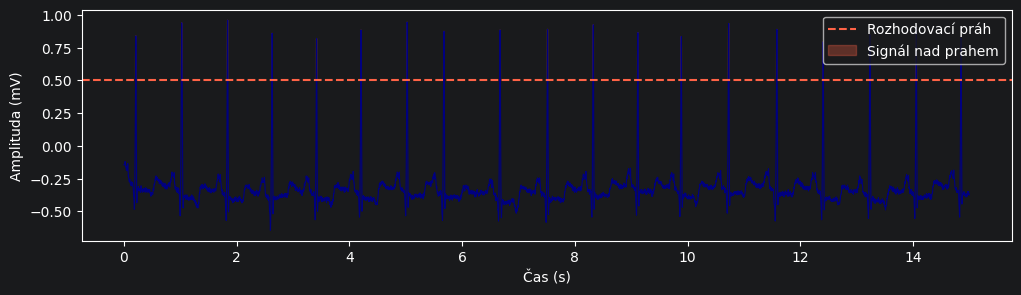

In [2]:
PRAH = 0.5

nad_prahem = np.greater(ekg, PRAH)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8, color="navy")
ax.axhline(y=PRAH, color="tomato", linestyle="--", label="Rozhodovací práh")
ax.fill_between(x=t, y1=PRAH, y2=ekg, where=nad_prahem, alpha=0.3, color="tomato", label="Signál nad prahem")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.legend(loc="upper right")
plt.show()

Nalezeno vrcholů: 19


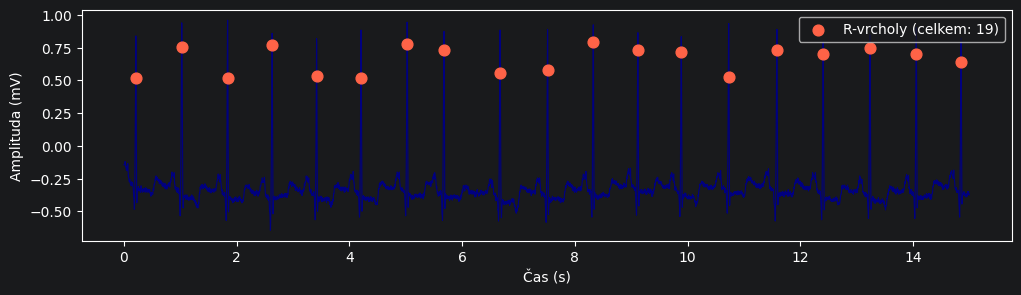

In [3]:
vrcholy = np.logical_and(nad_prahem, np.logical_not(np.roll(nad_prahem, -1)))
vrcholy[-1] = False

vrcholy_idx = np.nonzero(vrcholy)[0]

print(f"Nalezeno vrcholů: {len(vrcholy_idx)}")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8, color="navy")
ax.scatter(t[vrcholy_idx], ekg[vrcholy_idx], s=60, color="tomato", zorder=5, label=f"R-vrcholy (celkem: {len(vrcholy_idx)})")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.legend(loc="upper right")
plt.show()

In [4]:
cas_vrcholu = t[vrcholy_idx]
rr_intervaly = np.diff(cas_vrcholu)
tf_bpm = 60.0 / np.average(rr_intervaly)

print(f"Průměrný R-R interval: {rr_intervaly.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.8 BPM


Klidová TF (BPM):  ['73.8', '67.0', '62.0', '65.0', '68.0', '63.0', '67.0']
Zátěžová TF (BPM): ['65.7', '98.0', '103.0', '107.0', '95.0', '101.0']


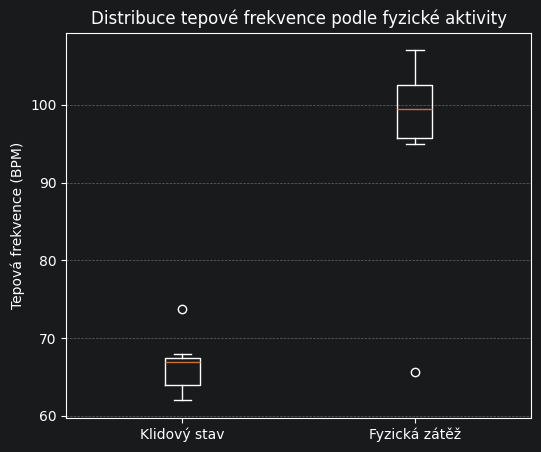

In [5]:
PRAH = 0.5

def spocitej_tf(soubor):
    nactena_data = np.loadtxt(soubor, skiprows=1)
    osa_t = nactena_data[:, 0]
    osa_y = nactena_data[:, 1]

    logicka_maska = np.greater(osa_y, PRAH)
    detekovano = np.logical_and(logicka_maska, np.logical_not(np.roll(logicka_maska, -1)))
    detekovano[-1] = False

    indexy = np.nonzero(detekovano)[0]
    rozdily_casu = np.diff(osa_t[indexy])

    return 60.0 / np.average(rozdily_casu)

tf_klid = list(map(spocitej_tf, files_klid))
tf_zatez = list(map(spocitej_tf, files_zatez))

print("Klidová TF (BPM): ", [f"{x:.1f}" for x in tf_klid])
print("Zátěžová TF (BPM):", [f"{x:.1f}" for x in tf_zatez])

fig, osa = plt.subplots(figsize=(6, 5))
osa.boxplot([tf_klid, tf_zatez], tick_labels=["Klidový stav", "Fyzická zátěž"])
osa.set_ylabel("Tepová frekvence (BPM)")
osa.set_title("Distribuce tepové frekvence podle fyzické aktivity")
osa.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()